# Descouvemont Example 4: $\alpha + {}^{12}$C with closed channels

This notebook reconstructs the multi-channel optical-model example from Descouvemont's paper where excited-target channels are closed at low energy and progressively open as the energy increases.

We will:

1. visualize the channel thresholds and the eight-channel structure,
2. evaluate the published five-energy grid with the direct `R`-matrix path,
3. inspect the open-channel first-column amplitudes and phases, and
4. finish with a dense energy scan plot of the open-channel observables (tagged `skip-benchmark`).


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

import lax as lm
from lax._descouvemont_utils import (
    alpha_c12_channels,
    alpha_c12_open_channel_count,
    alpha_c12_potential,
    first_column_amplitudes_and_phases,
)
from lax.boundary import BoundaryValues
from lax.solvers.observables import _decouple_closed_channels, _project_open_channels

ALPHA_C12_ENERGIES = np.array([4.0, 8.0, 12.0, 16.0, 20.0], dtype=np.float64)
CHANNEL_RADIUS = 11.0
BASIS_SIZE = 80
CHANNELS = alpha_c12_channels()
CHANNEL_LABELS = [
    '$0^+, L=3$',
    '$2^+, L=1$', '$2^+, L=3$', '$2^+, L=5$',
    '$4^+, L=1$', '$4^+, L=3$', '$4^+, L=5$', '$4^+, L=7$',
]
THRESHOLDS = np.array([channel.threshold for channel in CHANNELS], dtype=np.float64)


def smatrix_from_direct_rmatrix(solver: lm.boundary._types.Solver, potential) -> list[np.ndarray]:
    r_values = solver.rmatrix_direct(potential)
    matrices: list[np.ndarray] = []
    for energy_index in range(r_values.shape[0]):
        decoupled_r = _decouple_closed_channels(
            r_values[energy_index],
            solver.boundary.H_plus[energy_index],
            solver.boundary.H_plus_p[energy_index],
            solver.boundary.is_open[energy_index],
        )
        projected_r, projected_boundary = _project_open_channels(
            decoupled_r,
            solver.boundary.H_plus[energy_index],
            solver.boundary.H_minus[energy_index],
            solver.boundary.H_plus_p[energy_index],
            solver.boundary.H_minus_p[energy_index],
            solver.boundary.is_open[energy_index],
            solver.boundary.k[energy_index],
        )
        smatrix = lm.spectral.smatrix_from_R(
            projected_r,
            BoundaryValues(
                H_plus=projected_boundary.H_plus,
                H_minus=projected_boundary.H_minus,
                H_plus_p=projected_boundary.H_plus_p,
                H_minus_p=projected_boundary.H_minus_p,
                is_open=projected_boundary.is_open,
                k=projected_boundary.k,
            ),
        )
        open_count = alpha_c12_open_channel_count(float(solver.energies[energy_index]))
        matrices.append(np.asarray(smatrix)[:open_count, :open_count])
    return matrices


## Threshold structure

At 4 MeV only the elastic channel is open. At 8 and 12 MeV the three $2^+$ channels open. Above 14.08 MeV the $4^+$ channels open as well, which is why the paper's first-column output jumps from 1 to 4 to 8 entries.

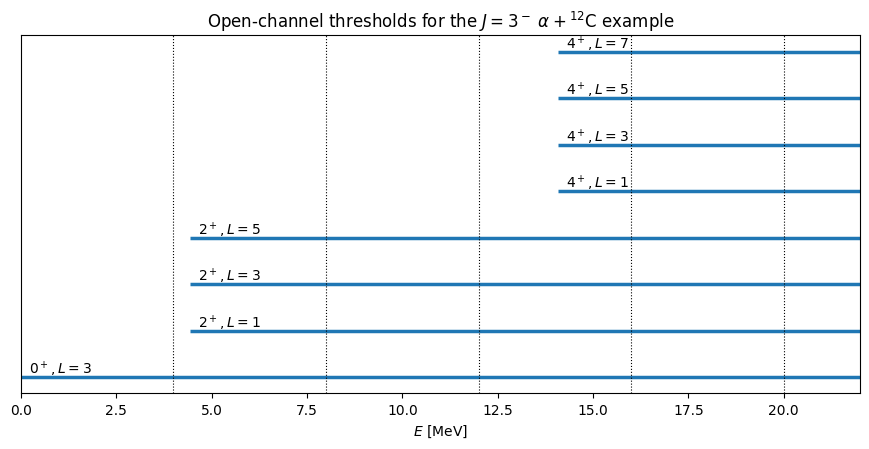

In [2]:
fig, ax = plt.subplots(figsize=(8.8, 4.6))
for index, (label, threshold) in enumerate(zip(CHANNEL_LABELS, THRESHOLDS, strict=True)):
    ax.hlines(index, threshold, 22.0, linewidth=2.5)
    ax.text(threshold + 0.2, index + 0.08, label)
for energy in ALPHA_C12_ENERGIES:
    ax.axvline(energy, color='k', linestyle=':', linewidth=0.8)
ax.set(
    xlabel='$E$ [MeV]',
    yticks=[],
    title='Open-channel thresholds for the $J=3^-$ $\\alpha+{}^{12}$C example',
    xlim=(0.0, 22.0),
)
plt.tight_layout()


## Published five-energy grid

The paper prints the first column of the open-channel collision matrix at 4, 8, 12, 16, and 20 MeV for a channel radius of 11 fm. We use the direct `R`-matrix path here because it naturally exposes the compile-time energy grid and keeps the closed-channel reduction explicit.

E =    4 MeV  open channels = 1
  amplitudes: [0.621745]
  phases:     [-0.09828]
E =    8 MeV  open channels = 4
  amplitudes: [0.18582  0.044407 0.24111  0.055339]
  phases:     [-1.03036   1.52644   1.21187  -0.325319]
E =   12 MeV  open channels = 4
  amplitudes: [0.083964 0.056117 0.051803 0.03628 ]
  phases:     [ 1.168909  0.864179  0.668615 -0.013703]
E =   16 MeV  open channels = 8
  amplitudes: [0.040892 0.027382 0.032126 0.046506 0.005464 0.001646 0.000831 0.000764]
  phases:     [ 0.320394  0.187215 -0.067887 -0.340283  1.064928  0.629912  0.21313
  0.111936]
E =   20 MeV  open channels = 8
  amplitudes: [0.02833  0.019963 0.022141 0.019322 0.005599 0.008828 0.02145  0.034082]
  phases:     [-0.418986 -0.614352 -0.698125 -1.229896  0.312444 -0.01628  -0.174996
  1.267878]


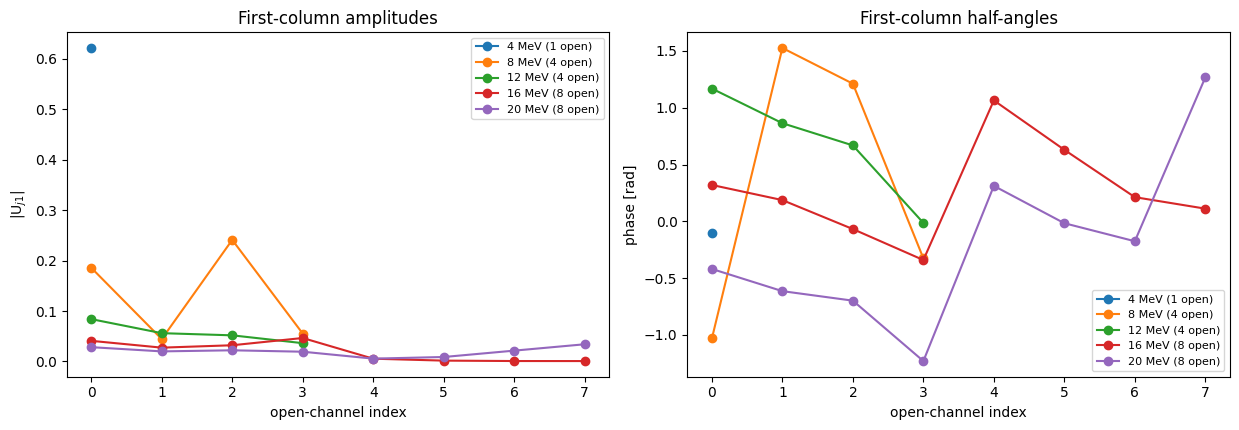

In [3]:
solver = lm.compile(
    mesh=lm.MeshSpec('legendre', 'x', n=BASIS_SIZE, scale=CHANNEL_RADIUS),
    channels=CHANNELS,
    operators=('T+L', '1/r^2'),
    solvers=('rmatrix_direct',),
    energies=ALPHA_C12_ENERGIES,
    method='linear_solve',
    V_is_complex=True,
    z1z2=(2, 6),
)
potential = lm.assemble_local(solver.mesh, alpha_c12_potential, n_channels=len(CHANNELS))
smatrices = smatrix_from_direct_rmatrix(solver, potential)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for energy_index, energy in enumerate(ALPHA_C12_ENERGIES):
    open_count = alpha_c12_open_channel_count(float(energy))
    amplitudes, phases = first_column_amplitudes_and_phases(smatrices[energy_index], open_count)
    label = f'{energy:.0f} MeV ({open_count} open)'
    axes[0].plot(np.arange(open_count), amplitudes, 'o-', label=label)
    axes[1].plot(np.arange(open_count), phases, 'o-', label=label)
    print(f'E = {energy:4.0f} MeV  open channels = {open_count}')
    print('  amplitudes:', np.array2string(amplitudes, precision=6))
    print('  phases:    ', np.array2string(phases, precision=6))

axes[0].set(xlabel='open-channel index', ylabel='|U$_{j1}$|', title='First-column amplitudes')
axes[1].set(xlabel='open-channel index', ylabel='phase [rad]', title='First-column half-angles')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()


## Dense energy scan

These cells scan a finer grid to show how the number of open channels changes with energy and how the first-column amplitudes/phases evolve. They are tagged `skip-benchmark` to keep the automated notebook run light.

In [4]:
%%time
scan_energies = np.linspace(3.5, 20.0, 50)
scan_solver = lm.compile(
    mesh=lm.MeshSpec('legendre', 'x', n=48, scale=11.0),
    channels=CHANNELS,
    operators=('T+L', '1/r^2'),
    solvers=('rmatrix_direct',),
    energies=scan_energies,
    method='linear_solve',
    V_is_complex=True,
    z1z2=(2, 6),
)
scan_potential = lm.assemble_local(scan_solver.mesh, alpha_c12_potential, n_channels=len(CHANNELS))
scan_smatrices = smatrix_from_direct_rmatrix(scan_solver, scan_potential)


CPU times: user 4min 35s, sys: 418 ms, total: 4min 36s
Wall time: 1min 10s


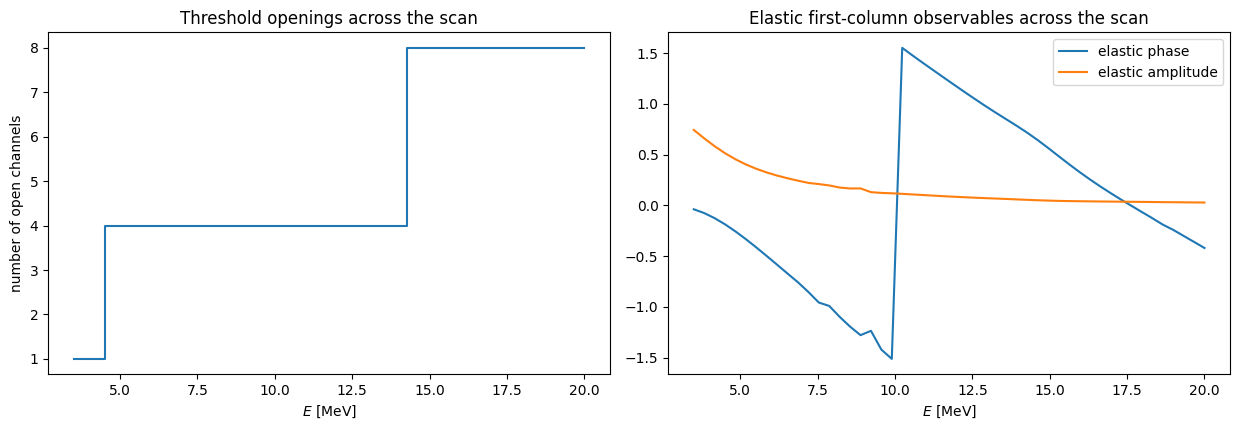

In [5]:
elastic_amplitude = []
elastic_phase = []
open_counts = []
for energy, smatrix in zip(scan_energies, scan_smatrices, strict=True):
    open_count = alpha_c12_open_channel_count(float(energy))
    amplitudes, phases = first_column_amplitudes_and_phases(smatrix, open_count)
    open_counts.append(open_count)
    elastic_amplitude.append(amplitudes[0])
    elastic_phase.append(phases[0])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].step(scan_energies, open_counts, where='post')
axes[0].set(xlabel='$E$ [MeV]', ylabel='number of open channels', title='Threshold openings across the scan')
axes[1].plot(scan_energies, elastic_phase, label='elastic phase')
axes[1].plot(scan_energies, elastic_amplitude, label='elastic amplitude')
axes[1].set(xlabel='$E$ [MeV]', title='Elastic first-column observables across the scan')
axes[1].legend()
plt.tight_layout()
